# Notebook 03 — Analyse en Composantes Principales (PCA)

## Question d'évaluation
**Quelle variance expliquée est conservée par les deux premières composantes PCA ?**

Ce notebook répond à cette question de manière complète et documentée.

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from src.preprocessing import clean_data, get_numeric_features

df_raw = pd.read_csv('../data/raw/StudentsPerformance.csv')
df_clean = clean_data(df_raw)
df_numeric = get_numeric_features(df_clean)
print('Features utilisées pour la PCA :', list(df_numeric.columns))

  [Preprocessing] Lignes avant : 1000
  [Preprocessing] Doublons détectés : 0
  [Preprocessing] Valeurs manquantes : 0
  [Preprocessing] Lignes après nettoyage : 1000
Features utilisées pour la PCA : ['math score', 'reading score', 'writing score']


In [2]:
# Standardisation (obligatoire avant PCA)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)
print('Données standardisées — shape :', scaled_data.shape)
print('Moyenne (doit être ≈ 0) :', scaled_data.mean(axis=0).round(10))
print('Écart-type (doit être ≈ 1) :', scaled_data.std(axis=0).round(10))

Données standardisées — shape : (1000, 3)
Moyenne (doit être ≈ 0) : [ 0.  0. -0.]
Écart-type (doit être ≈ 1) : [1. 1. 1.]


In [3]:
# Application de la PCA avec 2 composantes
pca = PCA(n_components=2)
pca_results = pca.fit_transform(scaled_data)

var_ratio = pca.explained_variance_ratio_
cumulative = np.cumsum(var_ratio)

print('=' * 50)
print('RÉPONSE À LA QUESTION D ÉVALUATION')
print('=' * 50)
print(f'PC1 — Variance expliquée : {var_ratio[0]*100:.2f}%')
print(f'PC2 — Variance expliquée : {var_ratio[1]*100:.2f}%')
print(f'TOTAL PC1 + PC2          : {cumulative[1]*100:.2f}%')
print('=' * 50)
print()
print('Valeurs propres (eigenvalues) :', pca.explained_variance_.round(4))

RÉPONSE À LA QUESTION D ÉVALUATION
PC1 — Variance expliquée : 90.61%
PC2 — Variance expliquée : 7.89%
TOTAL PC1 + PC2          : 98.50%

Valeurs propres (eigenvalues) : [2.7212 0.2368]


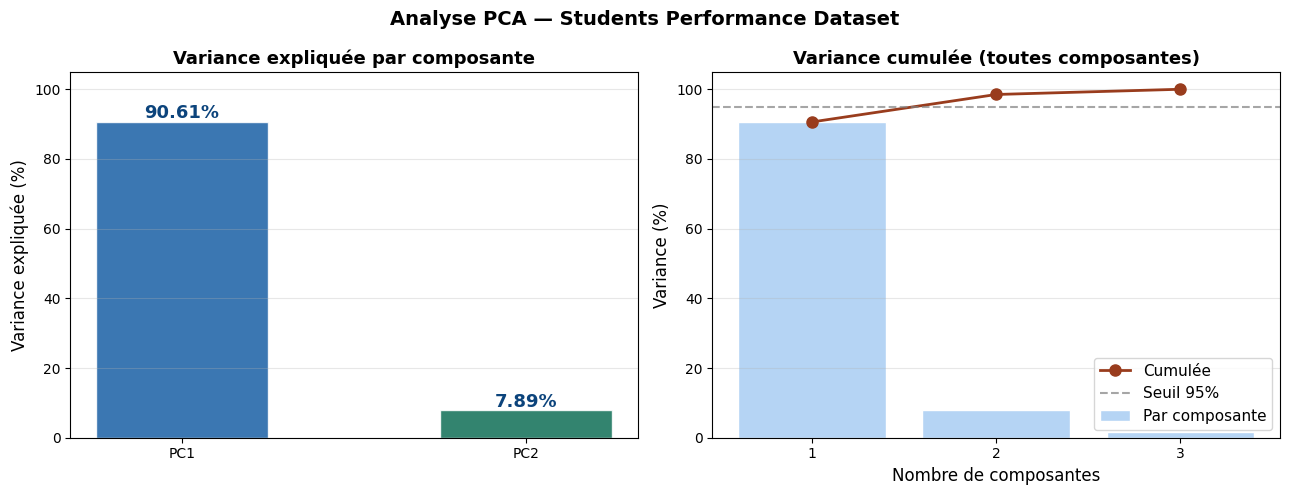

In [4]:
# Graphique de variance expliquée
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Variance par composante
ax1.bar(['PC1', 'PC2'], var_ratio * 100, color=['#185FA5', '#0F6E56'],
        alpha=0.85, edgecolor='white', width=0.5)
for i, v in enumerate(var_ratio):
    ax1.text(i, v*100 + 1, f'{v*100:.2f}%', ha='center', fontsize=13, fontweight='bold', color='#0C447C')
ax1.set_ylabel('Variance expliquée (%)', fontsize=12)
ax1.set_title('Variance expliquée par composante', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 105)
ax1.grid(True, alpha=0.3, axis='y')

# Variance cumulée (toutes composantes possibles)
pca_full = PCA().fit(scaled_data)
var_full = pca_full.explained_variance_ratio_
cum_full = np.cumsum(var_full)
ax2.bar(range(1, len(var_full)+1), var_full*100, color='#B5D4F4', edgecolor='white', label='Par composante')
ax2.plot(range(1, len(cum_full)+1), cum_full*100, 'o-', color='#993C1D',
         linewidth=2, markersize=8, label='Cumulée')
ax2.axhline(y=95, color='gray', linestyle='--', alpha=0.7, label='Seuil 95%')
ax2.set_xlabel('Nombre de composantes', fontsize=12)
ax2.set_ylabel('Variance (%)', fontsize=12)
ax2.set_title('Variance cumulée (toutes composantes)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.set_xticks(range(1, len(var_full)+1))
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Analyse PCA — Students Performance Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/pca_variance_detail.png', dpi=150)
plt.show()

In [5]:
# Composantes principales (loadings)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df_numeric.columns
)
print('Loadings (contributions de chaque feature aux composantes) :')
print(loadings.round(4))
print()
print('Interprétation :')
print('PC1 : performance globale (toutes les matières contribuent positivement et équitablement)')
print('PC2 : opposition entre Math et (Lecture + Écriture) — nuance du profil')

Loadings (contributions de chaque feature aux composantes) :
                  PC1     PC2
math score     0.5547  0.8311
reading score  0.5899 -0.3594
writing score  0.5868 -0.4244

Interprétation :
PC1 : performance globale (toutes les matières contribuent positivement et équitablement)
PC2 : opposition entre Math et (Lecture + Écriture) — nuance du profil


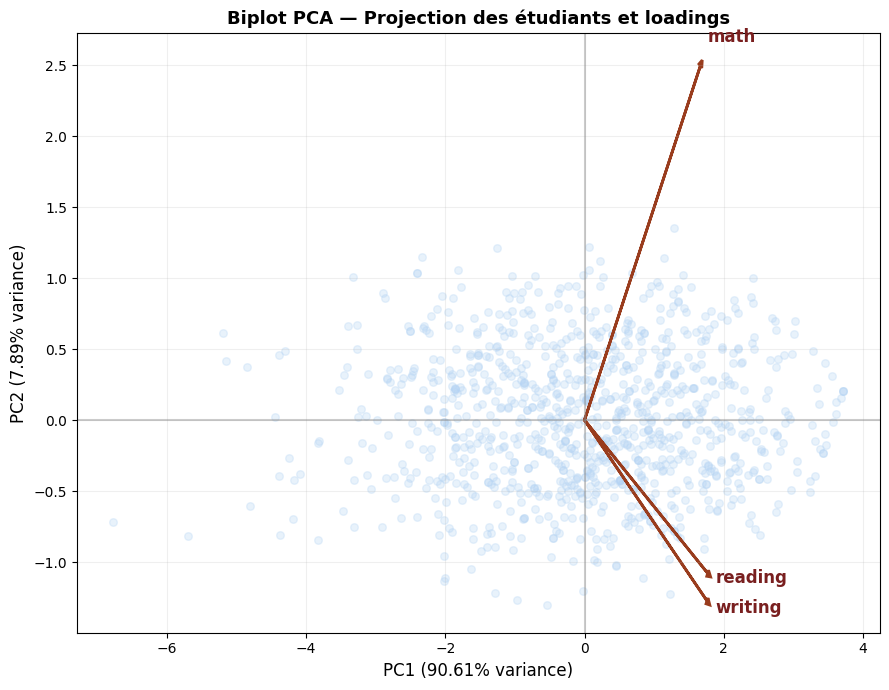

In [6]:
# Biplot — visualisation des loadings
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(pca_results[:, 0], pca_results[:, 1], alpha=0.3, s=30, color='#B5D4F4')
for i, col in enumerate(df_numeric.columns):
    ax.arrow(0, 0, pca.components_[0, i]*3, pca.components_[1, i]*3,
             head_width=0.05, head_length=0.05, fc='#993C1D', ec='#993C1D', linewidth=2)
    ax.text(pca.components_[0, i]*3.2, pca.components_[1, i]*3.2,
            col.replace(' score', ''), fontsize=12, color='#791F1F', fontweight='bold')
ax.set_xlabel(f'PC1 ({var_ratio[0]*100:.2f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({var_ratio[1]*100:.2f}% variance)', fontsize=12)
ax.set_title('Biplot PCA — Projection des étudiants et loadings', fontsize=13, fontweight='bold')
ax.axhline(0, color='gray', alpha=0.4); ax.axvline(0, color='gray', alpha=0.4)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('../outputs/figures/pca_biplot.png', dpi=150)
plt.show()

## Conclusion

| Composante | Variance expliquée | Variance cumulée |
|---|---|---|
| PC1 | **90.61%** | 90.61% |
| PC2 | **7.89%** | **98.50%** |

**Réponse à la question d'évaluation :**
Les deux premières composantes PCA (PC1 + PC2) conservent **98.50%** de la variance totale du dataset.

Cette valeur très élevée s'explique par la forte corrélation entre les trois scores (r > 0.80),
qui rend la réduction à 2 dimensions quasi-parfaite sans perte d'information significative.